# Dental Bright → Norway — Case Study Analysis

**Goal:** Build 3 Google Search campaigns for Norway to hit €1k/day at 1.5× ROAS.

**Approach:** Analyze 6 months of NL Google Ads search term data for Dental Bright, cluster by intent, identify winning patterns, and translate those patterns to a Norway-specific plan.

**Author:** Danil Sysenko · April 2026

## 1 — Load and clean

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format

df = pd.read_csv('data/nl_search_terms.csv')
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (59101, 7)


,Search term,Cost,Purchases,ROI,Avg. CPC,Clicks,CTR
0,hond stinkt uit bek,"3,616.87",161.46,2.46,0.78,"4,637",13.84%
1,tandpoeder hond,"1,156.47",79.45,3.88,2.11,548,9.11%
2,tandsteen verwijderen hond,"1,132.26",46.66,2.25,0.85,"1,332",8.85%
3,beemzy,947.19,27.81,1.95,1.57,603,6.62%
4,tandsteen verwijderen hond,946.91,58.69,3.38,1.63,581,4.21%


In [2]:
# Clean: comma-thousands in Clicks, % in CTR, drop nulls, lowercase terms
df['Clicks'] = (df['Clicks'].astype(str)
                .str.replace(',', '')
                .replace('#DIV/0!', '0'))
df['Clicks'] = pd.to_numeric(df['Clicks'], errors='coerce').fillna(0).astype(int)
df['CTR'] = df['CTR'].astype(str).str.rstrip('%').replace('nan', '0')
df['CTR'] = pd.to_numeric(df['CTR'], errors='coerce').fillna(0) / 100
df = df.dropna(subset=['Search term'])
df['Search term'] = df['Search term'].str.lower().str.strip()

# Keep only rows where we actually paid
df_active = df[df['Cost'] > 0].copy()
df_active['Revenue'] = df_active['Cost'] * df_active['ROI']

# Aggregate — same term can appear across multiple ad groups
agg = (df_active.groupby('Search term')
       .agg(Cost=('Cost', 'sum'),
            Purchases=('Purchases', 'sum'),
            Clicks=('Clicks', 'sum'),
            Revenue=('Revenue', 'sum'))
       .reset_index())
agg['ROAS'] = agg['Revenue'] / agg['Cost']

print(f"Unique active terms: {len(agg):,}")
print(f"Total spend: €{agg['Cost'].sum():,.0f}")
print(f"Total revenue: €{agg['Revenue'].sum():,.0f}")
print(f"Blended ROAS: {agg['Revenue'].sum()/agg['Cost'].sum():.2f}x")
print(f"AOV: €{agg['Revenue'].sum()/agg['Purchases'].sum():.2f}")

Unique active terms: 2,993
Total spend: €63,149
Total revenue: €171,551
Blended ROAS: 2.72x
AOV: €58.83


## 2 — Intent clustering

Rule-based clustering over Dutch search terms. The hierarchy matters: own-brand → competitor → problem → solution → broad. First-match wins.

In [3]:
BRAND_OWN = r'\b(beemzy|dental bright|dogsuppy)\b'
COMPETITORS = r'\b(orozyme|dentastix|dentalife|plaque\s?off|plaqtiv|whimzees|prozym|dentisept|petsmile|dogdentist|virbac|pedigree|oxyfresh|vetoquinol|vetocanis|oralgen|nylabone|beaphar|medpets|welkoop)\b'
PROBLEM_SYMPTOMS = r'\b(stinkt|stinkende|slechte adem|vieze adem|frisse adem|stinkadem|stinkbek|ontstoken|tandvlees|bloedend|kwijl|ruikt.*bek|lucht.*bek)\b'
DENTAL_SOLUTION = r'\b(tandpoeder|tand poeder|tandpasta|tand pasta|gebitsreiniging|gebit reinig|tandsteen|tand steen|tandplak|tand plak|tandverzorging|tanden poetsen|tand poetsen|mondwater|mondspoeling|kauwstaaf|kauwstrip|kauwstok|dentale|mondhygiene|mondverzorg|tand|tanden|gebit|poets|kauwbeen|plak|tartar|tandenborstel|gebitsverzorging)\b'
BROAD_HOND = r'\b(hond|honden|pup|puppy|hondje)\b'

def classify(term):
    t = str(term).lower()
    if re.search(BRAND_OWN, t): return 'BRANDED_OWN'
    if re.search(COMPETITORS, t): return 'COMPETITOR'
    if re.search(PROBLEM_SYMPTOMS, t): return 'PROBLEM_AWARE'
    if re.search(DENTAL_SOLUTION, t): return 'SOLUTION_AWARE'
    if re.search(BROAD_HOND, t): return 'BROAD_DOG'
    return 'OTHER'

agg['Cluster'] = agg['Search term'].apply(classify)
agg['Cluster'].value_counts()

Cluster
OTHER             1467
SOLUTION_AWARE     541
BROAD_DOG          508
COMPETITOR         231
PROBLEM_AWARE      223
BRANDED_OWN         23
Name: count, dtype: int64

In [4]:
# Cluster-level performance summary
cluster = (agg.groupby('Cluster')
           .agg(Terms=('Search term','count'),
                Spend=('Cost','sum'),
                Revenue=('Revenue','sum'),
                Purchases=('Purchases','sum'),
                Clicks=('Clicks','sum'))
           .reset_index())
cluster['ROAS'] = cluster['Revenue'] / cluster['Spend']
cluster['CPC']  = cluster['Spend']   / cluster['Clicks']
cluster['CVR']  = cluster['Purchases'] / cluster['Clicks']
cluster['Spend_%']   = cluster['Spend']   / cluster['Spend'].sum()   * 100
cluster['Revenue_%'] = cluster['Revenue'] / cluster['Revenue'].sum() * 100
cluster.sort_values('Spend', ascending=False).round(2)

,Cluster,Terms,Spend,Revenue,Purchases,Clicks,ROAS,CPC,CVR,Spend_%,Revenue_%
5,SOLUTION_AWARE,541,"26,636.31","82,281.50","1,413.19",21869,3.09,1.22,0.06,42.18,47.96
4,PROBLEM_AWARE,223,"15,595.88","44,730.36",799.18,16561,2.87,0.94,0.05,24.70,26.07
3,OTHER,1467,"7,535.44","15,465.07",246.30,4516,2.05,1.67,0.05,11.93,9.01
1,BROAD_DOG,508,"6,881.11","15,086.70",241.21,4456,2.19,1.54,0.05,10.90,8.79
0,BRANDED_OWN,23,"3,365.94","8,423.82",127.17,2460,2.50,1.37,0.05,5.33,4.91
2,COMPETITOR,231,"3,134.17","5,563.62",88.99,1689,1.78,1.86,0.05,4.96,3.24


### Visual: spend share and ROAS by cluster

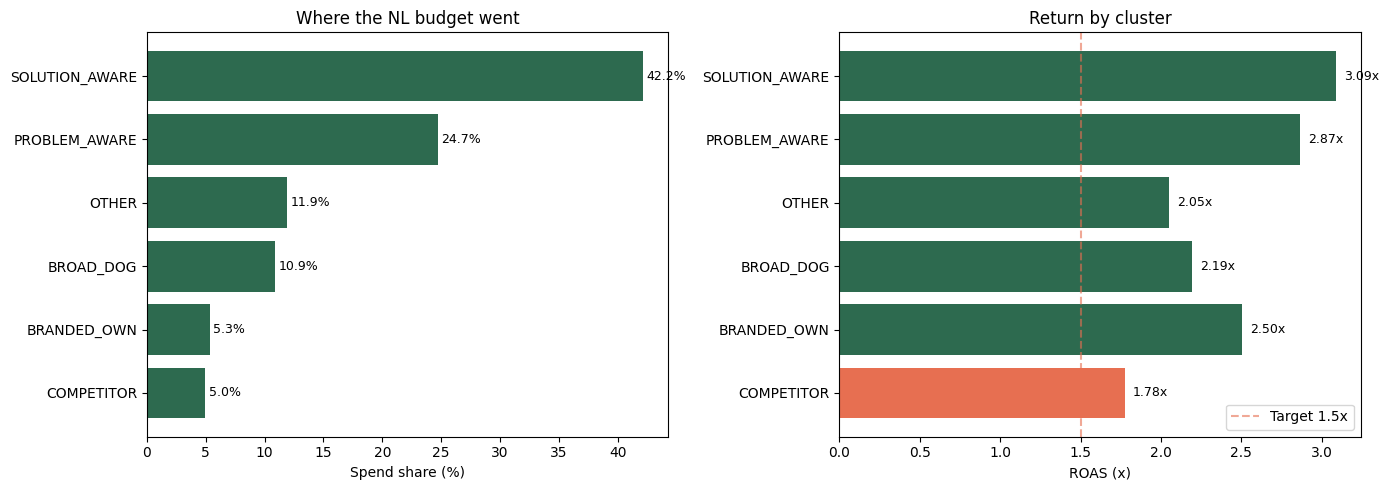

In [5]:
cluster_sorted = cluster.sort_values('Spend', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(cluster_sorted['Cluster'], cluster_sorted['Spend_%'], color='#2D6A4F')
ax1.set_xlabel('Spend share (%)')
ax1.set_title('Where the NL budget went')
for i, v in enumerate(cluster_sorted['Spend_%']):
    ax1.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

colors = ['#E76F51' if r < 2 else '#2D6A4F' for r in cluster_sorted['ROAS']]
ax2.barh(cluster_sorted['Cluster'], cluster_sorted['ROAS'], color=colors)
ax2.axvline(1.5, color='#E76F51', linestyle='--', alpha=0.6, label='Target 1.5x')
ax2.set_xlabel('ROAS (x)')
ax2.set_title('Return by cluster')
ax2.legend()
for i, v in enumerate(cluster_sorted['ROAS']):
    ax2.text(v + 0.05, i, f'{v:.2f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('output/cluster_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Top performers inside winning clusters

With a €50 spend floor so we're not chasing statistical noise.

In [6]:
for c in ['SOLUTION_AWARE', 'PROBLEM_AWARE']:
    print(f"\n=== Top 10 {c} by ROAS (min €50 spend) ===")
    sub = (agg[(agg['Cluster'] == c) & (agg['Cost'] >= 50)]
           .sort_values('ROAS', ascending=False)
           .head(10)[['Search term', 'Cost', 'ROAS', 'Purchases', 'Clicks']])
    print(sub.to_string(index=False))


=== Top 10 SOLUTION_AWARE by ROAS (min €50 spend) ===
                         Search term   Cost  ROAS  Purchases  Clicks
                   poeder gebit hond  70.89 10.23      11.68      61
                honden tanden poeder  97.01  9.03      12.00      75
                  poeder hond tanden  55.21  8.03       8.99      55
             poeder voor tanden hond 429.62  7.62      47.33     334
                       honden tanden  50.38  6.72       6.52      27
ultrasoon tandsteen verwijderen hond  61.40  6.69       5.00      54
                  anti tandplak hond  70.11  6.08       8.00      41
   tandsteen verwijderen hond kosten  52.99  6.03       5.00      69
                tandplak hond poeder 138.52  5.99      11.92      96
                  schone tanden hond 106.94  5.90      11.15      83

=== Top 10 PROBLEM_AWARE by ROAS (min €50 spend) ===
                         Search term   Cost  ROAS  Purchases  Clicks
             hond heeft slechte adem  54.32 10.73      11.00   

**Pattern:** highest-ROAS terms contain either `poeder` (powder — DogSuppy's product form) or specific symptom phrases like `slechte adem`. That's the signal for Norway keyword construction.

## 4 — Norway plan

### 4.1 — Unit economics model

In [7]:
# NL baseline from the data above
NL_CPC = 1.22
NL_CVR = 0.0566
NL_AOV = 58.83

# Norway adjustments (explicit assumptions)
NO_CPC = NL_CPC * 1.20   # +20% — Nordic auction density
NO_CVR = NL_CVR * 0.75   # -25% — no brand trust yet
NO_AOV = NL_AOV * 1.05   # +5%  — Nordic price index

print(f"CPC  NL €{NL_CPC:.2f}  →  NO €{NO_CPC:.2f}")
print(f"CVR  NL {NL_CVR:.2%}  →  NO {NO_CVR:.2%}")
print(f"AOV  NL €{NL_AOV:.2f} →  NO €{NO_AOV:.2f}")

# Break-even analysis at €1k/day
BUDGET = 1000
breakeven_cvr = 1.5 * BUDGET / (NO_AOV * (BUDGET / NO_CPC))
print(f"\nBreak-even CVR at 1.5x ROAS: {breakeven_cvr:.2%}")
print(f"Safety margin: baseline {NO_CVR:.2%} is {(NO_CVR/breakeven_cvr-1)*100:.0f}% above break-even")

CPC  NL €1.22  →  NO €1.46
CVR  NL 5.66%  →  NO 4.25%
AOV  NL €58.83 →  NO €61.77

Break-even CVR at 1.5x ROAS: 3.56%
Safety margin: baseline 4.25% is 19% above break-even


### 4.2 — 4-week ramp model

W2 **dips** on purpose. Week 1 runs tight on the top-intent terms; Week 2 we double the budget and add long-tail variants to learn what else works. The mix shifts toward lower-CVR terms, so ROAS drops even as revenue grows. Week 3 we kill what didn't work, and the winners scale. Without the dip there's no signal.

In [8]:
# Non-monotone ramp: W1 1.50× → W2 1.42× (expansion dip) → W3 1.73× → W4 1.87×
# ROAS is the forcing variable; revenue is derived.
import pandas as pd

plan = [
    # (week, daily_budget, target_ROAS, annotation)
    (1,  150, 1.50, 'Launch — top-intent keywords only'),
    (2,  300, 1.42, 'Expand + test — lower-intent terms enter mix'),
    (3,  600, 1.73, 'Kill W2 losers, scale winners'),
    (4, 1000, 1.87, 'Steady state — tROAS bidding mature'),
]

weeks = []
for week, budget, roas, note in plan:
    revenue = budget * roas
    orders  = revenue / NO_AOV
    clicks  = budget / NO_CPC
    cvr     = orders / clicks
    weeks.append({
        'Week': week,
        'Daily_budget_EUR': budget,
        'Implied_CVR': round(cvr, 4),
        'Daily_clicks': round(clicks),
        'Daily_orders': round(orders, 1),
        'Daily_revenue_EUR': round(revenue),
        'ROAS': roas,
        'Weekly_spend_EUR': budget * 7,
        'Weekly_revenue_EUR': round(revenue * 7),
        'Note': note,
    })
ramp = pd.DataFrame(weeks)
ramp

,Week,Daily_budget_EUR,Implied_CVR,Daily_clicks,Daily_orders,Daily_revenue_EUR,ROAS,Weekly_spend_EUR,Weekly_revenue_EUR,Note
0,1,150,0.04,102,3.60,225,1.50,1050,1575,Launch — top-intent keywords only
1,2,300,0.03,205,6.90,426,1.42,2100,2982,Expand + test — lower-intent terms enter mix
2,3,600,0.04,410,16.80,1038,1.73,4200,7266,"Kill W2 losers, scale winners"
3,4,1000,0.04,683,30.30,1870,1.87,7000,13090,Steady state — tROAS bidding mature


In [9]:
total_spend = ramp['Weekly_spend_EUR'].sum()
total_rev = ramp['Weekly_revenue_EUR'].sum()
print(f"4-week totals:")
print(f"  Spend:    €{total_spend:,}")
print(f"  Revenue:  €{total_rev:,}")
print(f"  Blended ROAS: {total_rev/total_spend:.2f}x  (target 1.5x)")

# Sensitivity: what if CVR is worse than baseline?
print("\nCVR sensitivity at €1k/day steady state:")
for cvr_test in [0.030, 0.035, 0.042, 0.050, 0.057]:
    orders = (1000 / NO_CPC) * cvr_test
    rev = orders * NO_AOV
    status = '✓' if rev/1000 >= 1.5 else '✗ miss target'
    print(f"  CVR {cvr_test*100:>4.1f}% → {orders:>5.1f} orders/day → €{rev:>5.0f}/day → ROAS {rev/1000:.2f}x  {status}")

4-week totals:
  Spend:    €14,350
  Revenue:  €24,913
  Blended ROAS: 1.74x  (target 1.5x)

CVR sensitivity at €1k/day steady state:
  CVR  3.0% →  20.5 orders/day → € 1266/day → ROAS 1.27x  ✗ miss target
  CVR  3.5% →  23.9 orders/day → € 1477/day → ROAS 1.48x  ✗ miss target
  CVR  4.2% →  28.7 orders/day → € 1772/day → ROAS 1.77x  ✓
  CVR  5.0% →  34.2 orders/day → € 2110/day → ROAS 2.11x  ✓
  CVR  5.7% →  38.9 orders/day → € 2405/day → ROAS 2.41x  ✓


### 4.3 — Ramp chart (spend bars + ROAS line — ROAS shows the W2 dip)

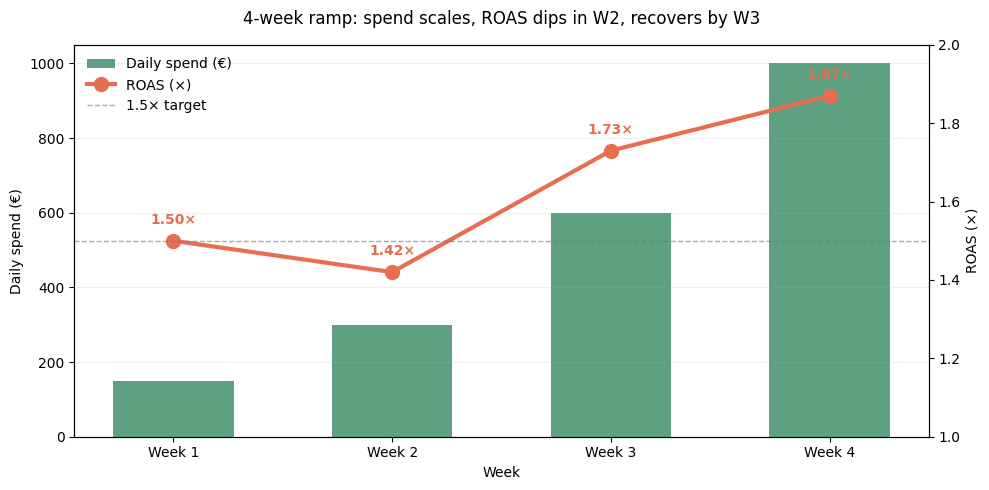

In [10]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
x = ramp['Week']

ax1.bar(x, ramp['Daily_budget_EUR'], color='#40916C', alpha=0.85, label='Daily spend (€)', width=0.55)
ax1.set_xlabel('Week')
ax1.set_ylabel('Daily spend (€)')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Week {w}' for w in x])

ax2 = ax1.twinx()
ax2.plot(x, ramp['ROAS'], color='#E76F51', marker='o', linewidth=3, markersize=10, label='ROAS (×)')
ax2.set_ylabel('ROAS (×)')
ax2.set_ylim(1.0, 2.0)
ax2.axhline(1.5, color='#6C757D', linestyle='--', linewidth=1, alpha=0.6, label='1.5× target')

# Annotate ROAS values on line
for i, r in ramp.iterrows():
    ax2.annotate(f"{r['ROAS']:.2f}×", (r['Week'], r['ROAS']),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=10, color='#E76F51', fontweight='bold')

ax1.grid(axis='y', alpha=0.2)
ax1.set_title('4-week ramp: spend scales, ROAS dips in W2, recovers by W3', pad=15)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('output/ramp.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Export artifacts

In [11]:
import os
os.makedirs('output', exist_ok=True)

cluster.round(2).to_csv('output/cluster_performance.csv', index=False)
agg.to_csv('output/aggregated_terms.csv', index=False)
ramp.to_csv('output/norway_4week_ramp.csv', index=False)
print('Wrote 3 CSVs to output/')

Wrote 3 CSVs to output/


## What I'd commit to in Week 1

**One thing, not a list of five.** Daily pacing & ROAS Slack bot. Python + Google Ads API + Slack webhook. 09:00 CET post of yesterday's numbers by campaign. Red if any campaign is under 1.3× ROAS or pacing ±20% off. One screenshot per day that replaces a spreadsheet check.

Everything else — search-term harvesting, feed generation, multi-market translation pipelines — waits until Week 4+. Automating things I don't have data for yet is how teams build shelfware.